# 02. Target과 전체 변수 확인

## 연구 가설

- H₀: 미혼 집단과 미혼 외 집단의 평균 `education-num`은 같다.
- H₁: 두 집단의 평균 `education-num`은 다르다.

이 노트북에서는 데이터에 어떤 값이 있는지 확인하고 Target과 변수 역할을 고정합니다.

In [1]:
from pathlib import Path
import sys

project_root = Path.cwd()
if project_root.name == 'notebooks':
    project_root = project_root.parent
if not (project_root / 'src').exists():
    raise RuntimeError('adult-marriage-education-analysis 프로젝트 루트에서 실행하세요.')
sys.path.insert(0, str(project_root))
project_root

PosixPath('/Users/beeyaaa/Workspace/SK-SKALA/day15_data/adult-marriage-education-analysis')

In [2]:
import pandas as pd
from IPython.display import Image, display
from src.config import EVER_MARRIED_STATUSES, NEVER_MARRIED_STATUS, TARGET
from src.data import (add_target, build_column_profile, build_feature_policy, load_pandas, resolve_raw_path)
from src.visualization import create_target_definition_chart

raw_df = load_pandas(resolve_raw_path(project_root))
prepared_df = add_target(raw_df)

## 1. 전체 컬럼 프로파일

In [3]:
column_profile = build_column_profile(raw_df)
column_profile.to_csv(project_root / 'reports' / 'tables' / 'column_profile.csv', index=False)
column_profile

,컬럼,데이터 타입,결측치 수,결측률(%),고유값 수,예시 값
0,age,int64,0,0.000000,73,"39, 50, 38, 53"
1,workclass,object,1836,5.638647,8,"State-gov, Self-emp-not-inc, Private, Federal-gov"
2,fnlwgt,int64,0,0.000000,21648,"77516, 83311, 215646, 234721"
3,education,object,0,0.000000,16,"Bachelors, HS-grad, 11th, Masters"
4,education-num,int64,0,0.000000,16,"13, 9, 7, 14"
5,marital-status,object,0,0.000000,7,"Never-married, Married-civ-spouse, Divorced, M..."
6,occupation,object,1843,5.660146,14,"Adm-clerical, Exec-managerial, Handlers-cleane..."
7,relationship,object,0,0.000000,6,"Not-in-family, Husband, Wife, Own-child"
8,race,object,0,0.000000,5,"White, Black, Asian-Pac-Islander, Amer-Indian-..."
9,sex,object,0,0.000000,2,"Male, Female"


## 2. 범주형 컬럼의 고유값과 빈도

In [4]:
categorical_columns = raw_df.select_dtypes(include=['object', 'string']).columns
for column in categorical_columns:
    print(f'\n[{column}]')
    print(raw_df[column].value_counts(dropna=False).to_string())


[workclass]
workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
NaN                  1836
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7

[education]
education
HS-grad         10501
Some-college     7291
Bachelors        5355
Masters          1723
Assoc-voc        1382
11th             1175
Assoc-acdm       1067
10th              933
7th-8th           646
Prof-school       576
9th               514
12th              433
Doctorate         413
5th-6th           333
1st-4th           168
Preschool          51

[marital-status]
marital-status
Married-civ-spouse       14976
Never-married            10683
Divorced                  4443
Separated                 1025
Widowed                    993
Married-spouse-absent      418
Married-AF-spouse           23

[occupation]
occupation
Prof-specialty       4140
Craft-repair         4099
Exec-managerial      4066
Adm-clerical   

## 3. 원본 marital-status 확인

In [5]:
marital_status_counts = raw_df['marital-status'].value_counts().rename_axis('혼인 상태').reset_index(name='표본 수')
marital_status_counts

,혼인 상태,표본 수
0,Married-civ-spouse,14976
1,Never-married,10683
2,Divorced,4443
3,Separated,1025
4,Widowed,993
5,Married-spouse-absent,418
6,Married-AF-spouse,23


## 4. 미혼/미혼 외 Target 생성

`Never-married`만 미혼(0)으로 정의합니다. `Married-*`, `Divorced`, `Separated`, `Widowed`는 미혼 외, 즉 혼인 경험 있음(1)으로 정의합니다.

In [6]:
print('미혼으로 분류한 원본 상태:', NEVER_MARRIED_STATUS)
print('미혼 외로 분류한 원본 상태:', sorted(EVER_MARRIED_STATUSES))
target_distribution = (
    prepared_df[TARGET].map({0: '미혼', 1: '미혼 외'})
    .value_counts().rename_axis('집단').reset_index(name='표본 수')
)
target_distribution['비율(%)'] = target_distribution['표본 수'] / len(prepared_df) * 100
target_distribution

미혼으로 분류한 원본 상태: Never-married
미혼 외로 분류한 원본 상태: ['Divorced', 'Married-AF-spouse', 'Married-civ-spouse', 'Married-spouse-absent', 'Separated', 'Widowed']


,집단,표본 수,비율(%)
0,미혼 외,21878,67.190811
1,미혼,10683,32.809189


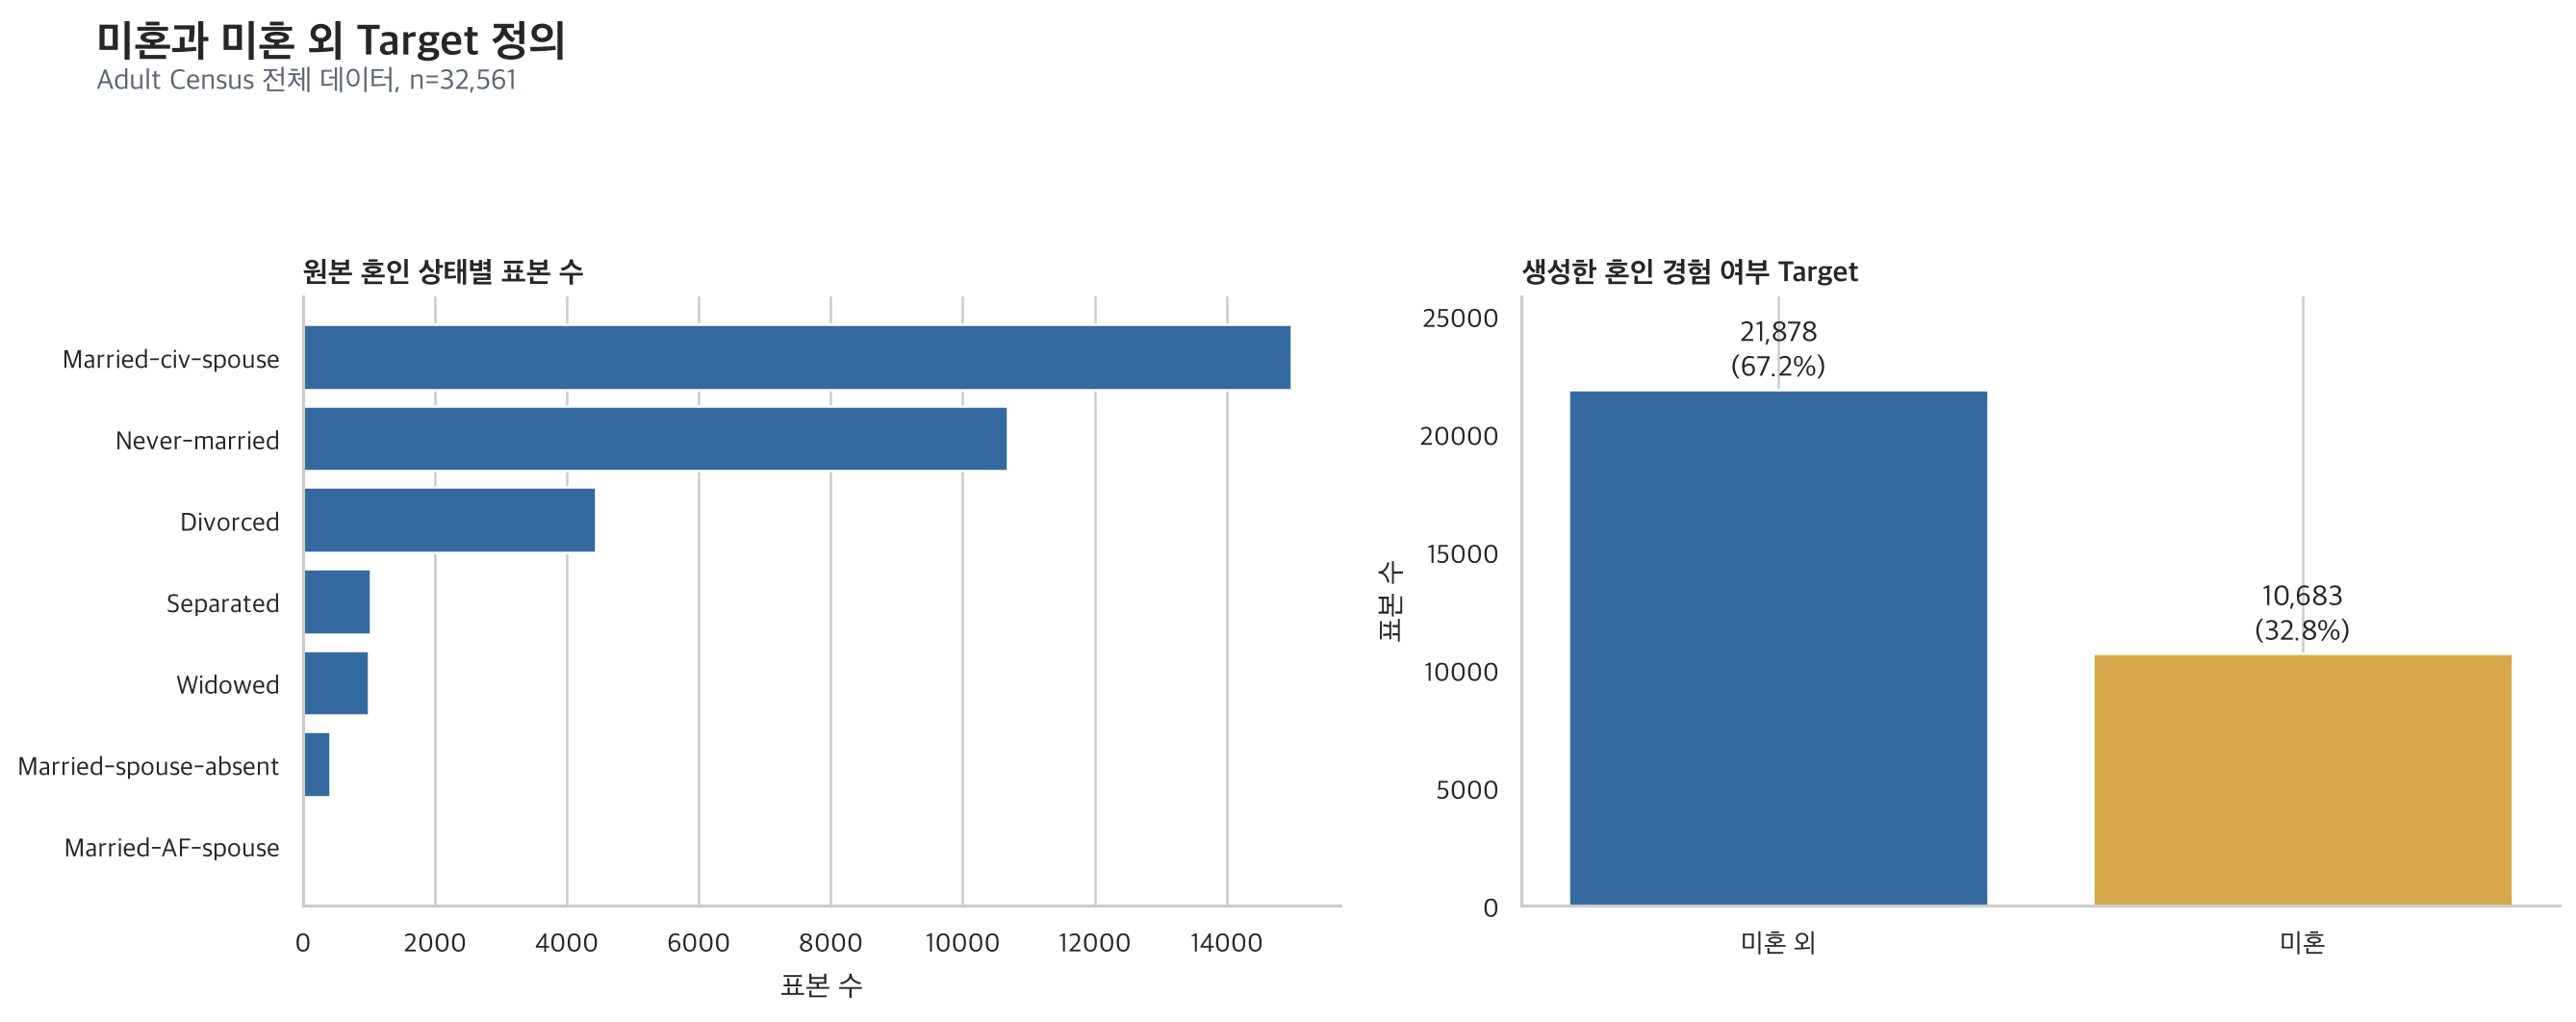

In [7]:
target_chart_path = create_target_definition_chart(
    prepared_df, project_root / 'reports' / 'figures' / '02_target_definition.png'
)
display(Image(filename=str(target_chart_path)))

![미혼과 미혼 외 Target 정의](../reports/figures/02_target_definition.png)

## 5. 변수 역할과 누수 방지 정책

In [8]:
feature_policy = build_feature_policy()
feature_policy.to_csv(project_root / 'reports' / 'tables' / 'feature_policy.csv', index=False)
feature_policy

,컬럼,역할,근거
0,ever_married,Target,"Never-married=0, 그 외 혼인 상태=1"
1,education-num,가설검정 변수,두 집단 평균 비교 대상
2,marital-status,모델 입력 제외,Target 생성에 사용한 원본 컬럼
3,relationship,모델 입력 제외,"Husband, Wife, Own-child 등이 혼인 상태를 직접 암시"
4,education,모델 입력 제외,education-num과 같은 학력 정보를 중복 표현
5,fnlwgt,모델 입력 제외,개인 특성이 아닌 Census 표본 가중치
6,race,공정성 점검,민감 특성으로 기본 모델과 분리
7,sex,공정성 점검,민감 특성으로 기본 모델과 분리
8,native-country,공정성 점검,민감 특성으로 기본 모델과 분리


## 다음 단계

03에서는 Train/Test를 먼저 나눈 후 Train 데이터만 사용해 교육 수준 분포, 숫자형 상관행렬, VIF, Welch t-test와 효과크기를 계산합니다.

In [9]:
assert prepared_df[TARGET].isin([0, 1]).all()
assert prepared_df[TARGET].isna().sum() == 0
assert target_chart_path.exists()
print('검증 완료: Target과 변수 역할이 정상적으로 정의됐습니다.')

검증 완료: Target과 변수 역할이 정상적으로 정의됐습니다.
